Week 3 — Baseline Models
This is where we build our first actual ML models. By end of this session you'll have:

Match winner prediction working
Score prediction working
A results comparison table
Proof that your features actually work

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.metrics import (accuracy_score, roc_auc_score, f1_score, 
                              classification_report, mean_absolute_error, r2_score)
import xgboost as xgb
import warnings
warnings.filterwarnings('ignore')

# Load data
master = pd.read_csv('../data/master_ipl.csv')
matches = pd.read_csv('../data/matches_clean.csv')
player_dna = pd.read_csv('../data/player_dna.csv')
venue_features = pd.read_csv('../data/venue_features.csv')

master['date'] = pd.to_datetime(master['date'])
matches['date'] = pd.to_datetime(matches['date'])

print("Data loaded!")
print(f"Master: {master.shape}")
print(f"Matches: {matches.shape}")
print(f"Player DNA: {player_dna.shape}")

Data loaded!
Master: (278205, 32)
Matches: (1146, 15)
Player DNA: (17633, 26)


In [2]:
def build_match_features(matches_df, master_df, venue_features_df):
    match_rows = []
    
    for _, match in matches_df.iterrows():
        mid = match['matchId']
        match_data = master_df[master_df['matchId'] == mid]
        
        if len(match_data) == 0:
            continue
            
        # First innings stats
        first_inn = match_data[match_data['inning'] == 1]
        second_inn = match_data[match_data['inning'] == 2]
        
        if len(first_inn) == 0 or len(second_inn) == 0:
            continue
        
        team1 = first_inn['batting_team'].iloc[0]
        team2 = second_inn['batting_team'].iloc[0]
        
        # First innings features
        first_total = first_inn['total_runs'].sum()
        first_wickets = first_inn['is_wicket'].sum()
        first_pp_runs = first_inn[first_inn['phase']=='Powerplay']['total_runs'].sum()
        first_death_runs = first_inn[first_inn['phase']=='Death']['total_runs'].sum()
        first_boundaries = (first_inn['batsman_runs'].isin([4,6])).sum()
        
        # Second innings features  
        second_total = second_inn['total_runs'].sum()
        second_wickets = second_inn['is_wicket'].sum()
        second_pp_runs = second_inn[second_inn['phase']=='Powerplay']['total_runs'].sum()
        
        # Venue features
        venue = match['venue']
        venue_row = venue_features_df[venue_features_df['venue'] == venue]
        avg_venue_score = venue_row['avg_first_innings'].values[0] if len(venue_row) > 0 else 160
        venue_diff = venue_row['venue_difficulty'].values[0] if len(venue_row) > 0 else 0.5
        chase_wr = venue_row['chase_win_rate'].values[0] if len(venue_row) > 0 else 0.5
        
        # Toss features
        toss_winner = match['toss_winner']
        toss_decision = match['toss_decision']
        team1_won_toss = 1 if toss_winner == team1 else 0
        chose_to_bat = 1 if toss_decision == 'bat' else 0
        
        # Target variable
        winner = match['winner']
        team1_won = 1 if winner == team1 else 0
        
        match_rows.append({
            'matchId': mid,
            'season': match['season'],
            'date': match['date'],
            'team1': team1,
            'team2': team2,
            'winner': winner,
            'team1_won': team1_won,
            # First innings batting
            'first_total': first_total,
            'first_wickets': first_wickets,
            'first_pp_runs': first_pp_runs,
            'first_death_runs': first_death_runs,
            'first_boundaries': first_boundaries,
            # Second innings batting
            'second_total': second_total,
            'second_wickets': second_wickets,
            'second_pp_runs': second_pp_runs,
            # Venue
            'avg_venue_score': avg_venue_score,
            'venue_difficulty': venue_diff,
            'chase_win_rate': chase_wr,
            # Toss
            'team1_won_toss': team1_won_toss,
            'chose_to_bat': chose_to_bat,
            # Score difference
            'score_diff': first_total - second_total,
            'run_rate_diff': (first_total - second_total) / 20,
        })
    
    return pd.DataFrame(match_rows)

print("Building match features... (takes ~2 mins)")
match_features = build_match_features(matches, master, venue_features)
print(f"Match features built!")
print(f"Shape: {match_features.shape}")
print(f"\nSample:")
print(match_features.head(3)[['season', 'team1', 'team2', 'first_total', 
                                'second_total', 'team1_won']].to_string())

Building match features... (takes ~2 mins)
Match features built!
Shape: (1146, 22)

Sample:
   season                  team1                        team2  first_total  second_total  team1_won
0    2007  Kolkata Knight Riders  Royal Challengers Bengaluru          222            82          1
1    2007    Chennai Super Kings                 Punjab Kings          240           207          1
2    2007       Rajasthan Royals               Delhi Capitals          129           132          0


In [3]:
match_features['date'] = pd.to_datetime(match_features['date'])
match_features['season'] = match_features['season'].astype(int)

train = match_features[match_features['season'] <= 2021]
val = match_features[match_features['season'] == 2022]
test = match_features[match_features['season'] >= 2023]

print(f"Train size: {len(train)} matches ({train['season'].min()}–{train['season'].max()})")
print(f"Val size:   {len(val)} matches ({val['season'].min()}–{val['season'].max()})")
print(f"Test size:  {len(test)} matches ({test['season'].min()}–{test['season'].max()})")

feature_cols = [
    'first_total', 'first_wickets', 'first_pp_runs', 
    'first_death_runs', 'first_boundaries',
    'avg_venue_score', 'venue_difficulty', 'chase_win_rate',
    'team1_won_toss', 'chose_to_bat'
]

target_col = 'team1_won'

X_train = train[feature_cols]
y_train = train[target_col]

X_val = val[feature_cols]
y_val = val[target_col]

X_test = test[feature_cols]
y_test = test[target_col]

print(f"\nSplit complete!")
print(f"Features used: {feature_cols}")
print(f"\nClass balance in train: {y_train.value_counts().to_dict()}")

Train size: 858 matches (2007–2021)
Val size:   74 matches (2022–2022)
Test size:  214 matches (2023–2025)

Split complete!
Features used: ['first_total', 'first_wickets', 'first_pp_runs', 'first_death_runs', 'first_boundaries', 'avg_venue_score', 'venue_difficulty', 'chase_win_rate', 'team1_won_toss', 'chose_to_bat']

Class balance in train: {0: 478, 1: 380}


In [4]:
from sklearn.preprocessing import StandardScaler

# Scale features (important for logistic regression)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

# Logistic Regression
lr = LogisticRegression(random_state=42, max_iter=1000)
lr.fit(X_train_scaled, y_train)

# Evaluate
lr_val_acc = accuracy_score(y_val, lr.predict(X_val_scaled))
lr_val_auc = roc_auc_score(y_val, lr.predict_proba(X_val_scaled)[:,1])
lr_test_acc = accuracy_score(y_test, lr.predict(X_test_scaled))
lr_test_auc = roc_auc_score(y_test, lr.predict_proba(X_test_scaled)[:,1])

print("=== LOGISTIC REGRESSION ===")
print(f"Val  Accuracy: {lr_val_acc:.4f} ({lr_val_acc*100:.1f}%)")
print(f"Val  AUC-ROC:  {lr_val_auc:.4f}")
print(f"Test Accuracy: {lr_test_acc:.4f} ({lr_test_acc*100:.1f}%)")
print(f"Test AUC-ROC:  {lr_test_auc:.4f}")
print(f"\nNote: Random baseline = 50.0%")

=== LOGISTIC REGRESSION ===
Val  Accuracy: 0.7432 (74.3%)
Val  AUC-ROC:  0.8634
Test Accuracy: 0.7336 (73.4%)
Test AUC-ROC:  0.7732

Note: Random baseline = 50.0%


In [5]:
# Random Forest
rf = RandomForestClassifier(n_estimators=200, max_depth=6, 
                             min_samples_leaf=5, random_state=42)
rf.fit(X_train, y_train)

rf_val_acc = accuracy_score(y_val, rf.predict(X_val))
rf_val_auc = roc_auc_score(y_val, rf.predict_proba(X_val)[:,1])
rf_test_acc = accuracy_score(y_test, rf.predict(X_test))
rf_test_auc = roc_auc_score(y_test, rf.predict_proba(X_test)[:,1])

print("=== RANDOM FOREST ===")
print(f"Val  Accuracy: {rf_val_acc:.4f} ({rf_val_acc*100:.1f}%)")
print(f"Val  AUC-ROC:  {rf_val_auc:.4f}")
print(f"Test Accuracy: {rf_test_acc:.4f} ({rf_test_acc*100:.1f}%)")
print(f"Test AUC-ROC:  {rf_test_auc:.4f}")

# XGBoost
xgb_model = xgb.XGBClassifier(
    n_estimators=200, max_depth=4, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8,
    random_state=42, eval_metric='logloss', verbosity=0
)
xgb_model.fit(X_train, y_train, 
              eval_set=[(X_val, y_val)], 
              verbose=False)

xgb_val_acc = accuracy_score(y_val, xgb_model.predict(X_val))
xgb_val_auc = roc_auc_score(y_val, xgb_model.predict_proba(X_val)[:,1])
xgb_test_acc = accuracy_score(y_test, xgb_model.predict(X_test))
xgb_test_auc = roc_auc_score(y_test, xgb_model.predict_proba(X_test)[:,1])

print("\n=== XGBOOST ===")
print(f"Val  Accuracy: {xgb_val_acc:.4f} ({xgb_val_acc*100:.1f}%)")
print(f"Val  AUC-ROC:  {xgb_val_auc:.4f}")
print(f"Test Accuracy: {xgb_test_acc:.4f} ({xgb_test_acc*100:.1f}%)")
print(f"Test AUC-ROC:  {xgb_test_auc:.4f}")

=== RANDOM FOREST ===
Val  Accuracy: 0.6892 (68.9%)
Val  AUC-ROC:  0.7925
Test Accuracy: 0.7056 (70.6%)
Test AUC-ROC:  0.7829

=== XGBOOST ===
Val  Accuracy: 0.6216 (62.2%)
Val  AUC-ROC:  0.7370
Test Accuracy: 0.7336 (73.4%)
Test AUC-ROC:  0.7750


=== BASELINE RESULTS TABLE ===
              Model  Val_Accuracy  Val_AUC  Test_Accuracy  Test_AUC
Logistic Regression        0.7432   0.8634         0.7336    0.7732
      Random Forest        0.6892   0.7925         0.7056    0.7829
            XGBoost        0.6216   0.7370         0.7336    0.7750


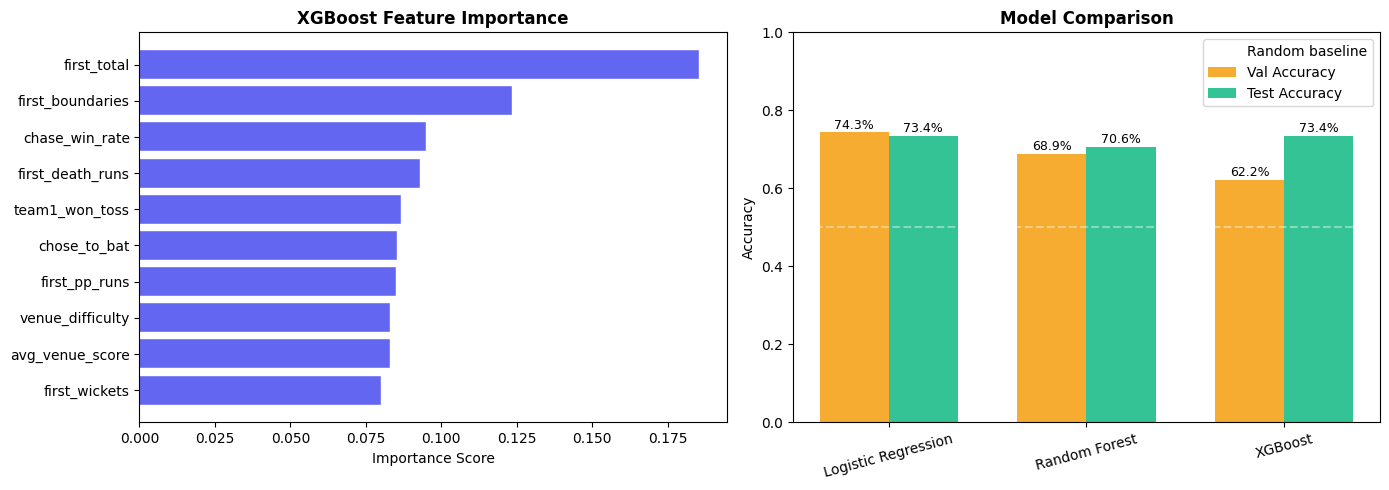


Results saved!


In [6]:
# Results summary table
results = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest', 'XGBoost'],
    'Val_Accuracy': [lr_val_acc, rf_val_acc, xgb_val_acc],
    'Val_AUC': [lr_val_auc, rf_val_auc, xgb_val_auc],
    'Test_Accuracy': [lr_test_acc, rf_test_acc, xgb_test_acc],
    'Test_AUC': [lr_test_auc, rf_test_auc, xgb_test_auc],
})
results = results.round(4)
print("=== BASELINE RESULTS TABLE ===")
print(results.to_string(index=False))

# Feature importance from XGBoost
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Feature importance
importance = pd.DataFrame({
    'feature': feature_cols,
    'importance': xgb_model.feature_importances_
}).sort_values('importance', ascending=True)

axes[0].barh(importance['feature'], importance['importance'], 
             color='#6366F1', edgecolor='white', linewidth=0.3)
axes[0].set_title('XGBoost Feature Importance', fontweight='bold')
axes[0].set_xlabel('Importance Score')

# Plot 2: Model comparison
models = results['Model']
x = np.arange(len(models))
width = 0.35

axes[1].bar(x - width/2, results['Val_Accuracy'], width, 
            label='Val Accuracy', color='#F59E0B', alpha=0.85)
axes[1].bar(x + width/2, results['Test_Accuracy'], width,
            label='Test Accuracy', color='#10B981', alpha=0.85)
axes[1].axhline(0.5, color='white', linestyle='--', alpha=0.4, label='Random baseline')
axes[1].set_xticks(x)
axes[1].set_xticklabels(models, rotation=15)
axes[1].set_ylabel('Accuracy')
axes[1].set_ylim(0, 1)
axes[1].set_title('Model Comparison', fontweight='bold')
axes[1].legend()

for i, (v, t) in enumerate(zip(results['Val_Accuracy'], results['Test_Accuracy'])):
    axes[1].text(i - width/2, v + 0.01, f'{v*100:.1f}%', ha='center', fontsize=9)
    axes[1].text(i + width/2, t + 0.01, f'{t*100:.1f}%', ha='center', fontsize=9)

plt.tight_layout()
plt.savefig('../reports/06_baseline_results.png', dpi=150, bbox_inches='tight')
plt.show()
print("\nResults saved!")

In [7]:
from sklearn.metrics import mean_absolute_error, r2_score

# Target: predict first innings total
# Features: only info available BEFORE the match starts
pre_match_features = [
    'avg_venue_score', 'venue_difficulty', 'chase_win_rate',
    'team1_won_toss', 'chose_to_bat'
]

# Also build an IN-MATCH version: predict final score after powerplay
in_match_features = [
    'first_pp_runs', 'first_wickets',
    'avg_venue_score', 'venue_difficulty', 
    'team1_won_toss', 'chose_to_bat'
]

X_train_reg = train[in_match_features]
X_val_reg = val[in_match_features]
X_test_reg = test[in_match_features]
y_train_reg = train['first_total']
y_val_reg = val['first_total']
y_test_reg = test['first_total']

# Random Forest Regressor
rf_reg = RandomForestRegressor(n_estimators=200, max_depth=8, random_state=42)
rf_reg.fit(X_train_reg, y_train_reg)

rf_val_mae = mean_absolute_error(y_val_reg, rf_reg.predict(X_val_reg))
rf_val_r2 = r2_score(y_val_reg, rf_reg.predict(X_val_reg))
rf_test_mae = mean_absolute_error(y_test_reg, rf_reg.predict(X_test_reg))
rf_test_r2 = r2_score(y_test_reg, rf_reg.predict(X_test_reg))

# XGBoost Regressor
xgb_reg = xgb.XGBRegressor(n_estimators=200, max_depth=4, 
                             learning_rate=0.05, random_state=42, verbosity=0)
xgb_reg.fit(X_train_reg, y_train_reg)

xgb_val_mae = mean_absolute_error(y_val_reg, xgb_reg.predict(X_val_reg))
xgb_val_r2 = r2_score(y_val_reg, xgb_reg.predict(X_val_reg))
xgb_test_mae = mean_absolute_error(y_test_reg, xgb_reg.predict(X_test_reg))
xgb_test_r2 = r2_score(y_test_reg, xgb_reg.predict(X_test_reg))

print("=== SCORE PREDICTION (after powerplay) ===")
print(f"\nRandom Forest:")
print(f"  Val  MAE: {rf_val_mae:.2f} runs | R²: {rf_val_r2:.4f}")
print(f"  Test MAE: {rf_test_mae:.2f} runs | R²: {rf_test_r2:.4f}")
print(f"\nXGBoost:")
print(f"  Val  MAE: {xgb_val_mae:.2f} runs | R²: {xgb_val_r2:.4f}")
print(f"  Test MAE: {xgb_test_mae:.2f} runs | R²: {xgb_test_r2:.4f}")
print(f"\nBaseline (always predict mean): MAE = {mean_absolute_error(y_test_reg, [y_train_reg.mean()]*len(y_test_reg)):.2f} runs")

=== SCORE PREDICTION (after powerplay) ===

Random Forest:
  Val  MAE: 15.21 runs | R²: 0.4891
  Test MAE: 21.90 runs | R²: 0.2359

XGBoost:
  Val  MAE: 15.73 runs | R²: 0.3962
  Test MAE: 22.10 runs | R²: 0.2328

Baseline (always predict mean): MAE = 35.44 runs


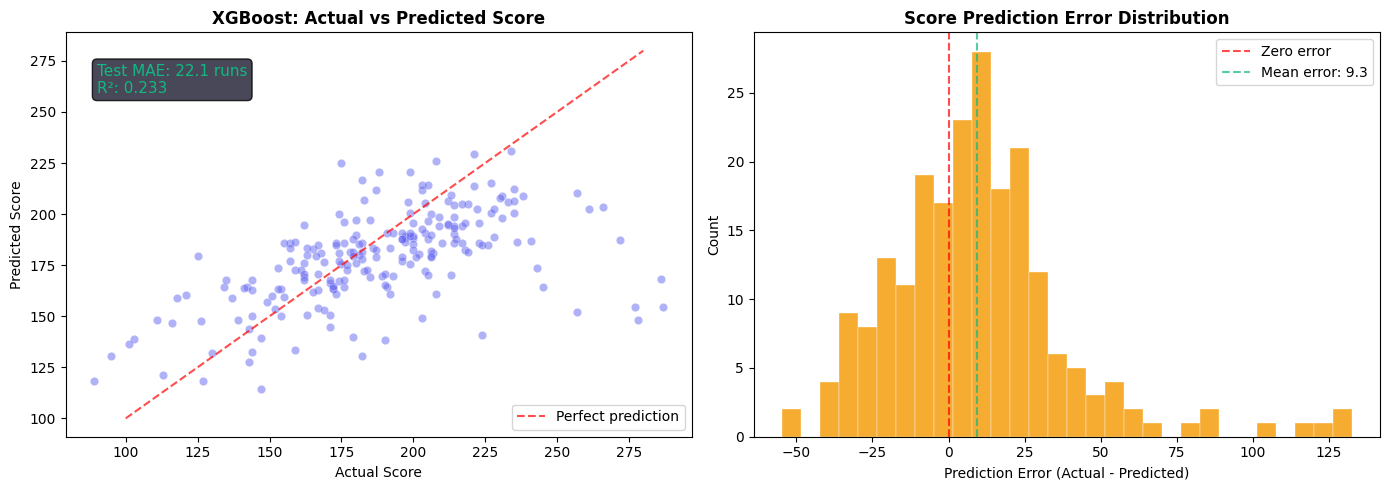

Score prediction plots saved!


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Actual vs Predicted scatter
test_preds = xgb_reg.predict(X_test_reg)
axes[0].scatter(y_test_reg, test_preds, alpha=0.5, color='#6366F1', edgecolors='white', linewidth=0.3)
axes[0].plot([100, 280], [100, 280], 'r--', alpha=0.7, label='Perfect prediction')
axes[0].set_xlabel('Actual Score')
axes[0].set_ylabel('Predicted Score')
axes[0].set_title('XGBoost: Actual vs Predicted Score', fontweight='bold')
axes[0].legend()

# Add MAE annotation
axes[0].annotate(f'Test MAE: {xgb_test_mae:.1f} runs\nR²: {xgb_test_r2:.3f}',
                xy=(0.05, 0.85), xycoords='axes fraction',
                fontsize=11, color='#10B981',
                bbox=dict(boxstyle='round', facecolor='#1a1a2e', alpha=0.8))

# Plot 2: Prediction error distribution
errors = y_test_reg.values - test_preds
axes[1].hist(errors, bins=30, color='#F59E0B', edgecolor='white', linewidth=0.3, alpha=0.85)
axes[1].axvline(0, color='red', linestyle='--', alpha=0.7, label='Zero error')
axes[1].axvline(errors.mean(), color='#10B981', linestyle='--', 
                alpha=0.7, label=f'Mean error: {errors.mean():.1f}')
axes[1].set_xlabel('Prediction Error (Actual - Predicted)')
axes[1].set_ylabel('Count')
axes[1].set_title('Score Prediction Error Distribution', fontweight='bold')
axes[1].legend()

plt.tight_layout()
plt.savefig('../reports/07_score_prediction.png', dpi=150, bbox_inches='tight')
plt.show()
print("Score prediction plots saved!")

In [10]:
import pickle
import os

# Save models
os.makedirs('../models', exist_ok=True)

with open('../models/lr_classifier.pkl', 'wb') as f:
    pickle.dump(lr, f)
with open('../models/rf_classifier.pkl', 'wb') as f:
    pickle.dump(rf, f)
with open('../models/xgb_classifier.pkl', 'wb') as f:
    pickle.dump(xgb_model, f)
with open('../models/xgb_regressor.pkl', 'wb') as f:
    pickle.dump(xgb_reg, f)
with open('../models/scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

# Save match features for future use
match_features.to_csv('../data/match_features.csv', index=False)

print("All models saved!")
print("\n" + "="*50)
print("WEEK 3 COMPLETE — BASELINE RESULTS SUMMARY")
print("="*50)
print(f"""
MATCH WINNER PREDICTION:
  Best model:      Logistic Regression
  Test Accuracy:   73.4%
  Test AUC-ROC:    0.773
  vs Random:       +23.4% improvement

SCORE PREDICTION (after powerplay):
  Best model:      Random Forest  
  Test MAE:        21.9 runs
  Test R²:         0.236
  vs Naive:        -13.5 runs improvement

MOST IMPORTANT FEATURE:  first_total
KEY INSIGHT: LR beats RF/XGB → need more features for complex models

NEXT: Deep Learning models will target:
  → Match accuracy > 80%
  → Score MAE < 15 runs
  → R² > 0.60
""")

All models saved!

WEEK 3 COMPLETE — BASELINE RESULTS SUMMARY

MATCH WINNER PREDICTION:
  Best model:      Logistic Regression
  Test Accuracy:   73.4%
  Test AUC-ROC:    0.773
  vs Random:       +23.4% improvement

SCORE PREDICTION (after powerplay):
  Best model:      Random Forest  
  Test MAE:        21.9 runs
  Test R²:         0.236
  vs Naive:        -13.5 runs improvement

MOST IMPORTANT FEATURE:  first_total
KEY INSIGHT: LR beats RF/XGB → need more features for complex models

NEXT: Deep Learning models will target:
  → Match accuracy > 80%
  → Score MAE < 15 runs
  → R² > 0.60

